In [1]:
# actor-critic的实现

import gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def show_animation(imgs):
    rc("animation", html="jshtml")
    fig, ax = plt.subplots(1, 1, figsize=(5, 3))
    frames = []

    text = ax.text(10, 20, "", fontsize=12, color="black")

    for i, img in enumerate(imgs):
        frame = [ax.imshow(img, animated=True)]
        frame.append(ax.text(10, 20, f"Step: {i + 1}", animated=True))  # Step数表示
        frames.append(frame)

    ax.axis("off")

    ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

    # 保存动画
    # ani.save("cartpole.mp4", writer="ffmpeg")
    ani.save("cartpole.gif", writer="pillow")

    plt.close(fig)
    return ani


def plot_loss(episode_list, return_list, filename):
    """绘制奖励图像"""
    f = plt.figure()
    plt.plot(episode_list, return_list)
    plt.xlabel("Episodes")
    plt.ylabel("Returns")
    plt.title("CartPole-v0")
    plt.show()
    f.savefig(filename, bbox_inches="tight")


class PolicyNet(nn.Module):
    """策略神经网络的结构"""

    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):  # x是S_t
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=1)  # Softmax得到概率分布
        return x


class ValueNet(nn.Module):
    """价值函数神经网络V_ω"""

    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = self.l2(x)  # 不用激活函数，直接输出V值
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98  # 折扣因子，未来奖励的权重
        self.lr_pi = 0.0002  # 策略网络学习率（较小，稳定训练）
        self.lr_v = 0.005  # 价值网络学习率（较大，快速收敛）
        self.action_size = 2  # 两个动作：左/右
        self.pi = PolicyNet(self.action_size)
        self.v = ValueNet()
        self.optimizer_pi = optim.Adam(self.pi.parameters(), lr=self.lr_pi)
        self.optimizer_v = optim.Adam(self.v.parameters(), lr=self.lr_v)

    def get_action(self, state):
        probs = self.pi(torch.tensor(state).unsqueeze(0)).squeeze(0)
        m = Categorical(probs)  # 创建分类分布
        action = m.sample().item()  # 根据概率采样动作
        return action, probs

    def update(self, state, next_state, reward, action_prob, done):
        state = torch.tensor(state).unsqueeze(0)
        next_state = torch.tensor(next_state).unsqueeze(0)

        # ① 计算价值网络的损失
        # td误差δ = R_t + γV(S_(t+1)) - V(S_t)
        # TD target = δ + V(S_t)
        target = reward + self.gamma * self.v(next_state) * (1 - done)
        target.detach()  # 从计算图剥离，变成一个常数
        # V(S_t)
        v = self.v(state)  # 当前状态的价值估计
        loss_fn = nn.MSELoss()  # MSE损失
        loss_v = loss_fn(v, target)

        # ② 计算策略网络的损失
        delta = target - v  # 必须从计算图中剥离出来
        loss_pi = -torch.log(action_prob) * delta.detach().item()

        self.optimizer_pi.zero_grad()
        self.optimizer_v.zero_grad()
        loss_v.backward()  # Critic梯度
        loss_pi.backward()  # Actor梯度
        self.optimizer_pi.step()
        self.optimizer_v.step()

C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for 

回合：0, 总奖励：28.0
回合：100, 总奖励：50.0
回合：200, 总奖励：161.0
回合：300, 总奖励：134.0
回合：400, 总奖励：200.0
回合：500, 总奖励：200.0
回合：600, 总奖励：200.0
回合：700, 总奖励：200.0
回合：800, 总奖励：200.0
回合：900, 总奖励：200.0
回合：1000, 总奖励：170.0
回合：1100, 总奖励：192.0
回合：1200, 总奖励：200.0
回合：1300, 总奖励：74.0
回合：1400, 总奖励：118.0
回合：1500, 总奖励：134.0
回合：1600, 总奖励：200.0
回合：1700, 总奖励：200.0
回合：1800, 总奖励：63.0
回合：1900, 总奖励：80.0
回合：2000, 总奖励：127.0
回合：2100, 总奖励：151.0
回合：2200, 总奖励：184.0
回合：2300, 总奖励：50.0
回合：2400, 总奖励：148.0
回合：2500, 总奖励：200.0
回合：2600, 总奖励：133.0
回合：2700, 总奖励：67.0
回合：2800, 总奖励：194.0
回合：2900, 总奖励：74.0


C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


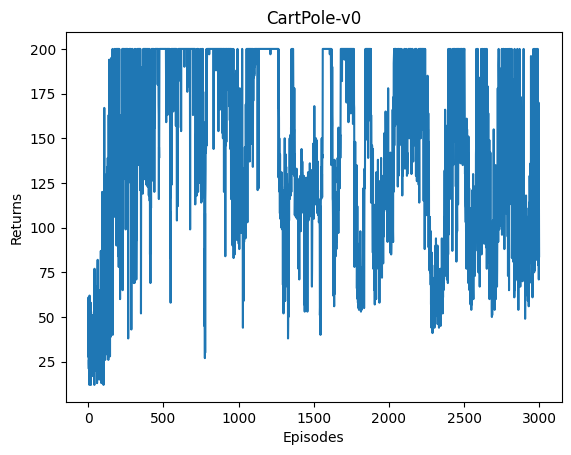

In [3]:
env = gym.make("CartPole-v0")
agent = Agent()
return_list = []
episode_list = []

for episode in range(3000):
    state = env.reset()  # S_0
    done = False
    total_reward = 0.0

    while not done:
        action, probs = agent.get_action(state)
        next_state, reward, done, _ = env.step(action)
        # 执行一个动作，更新一次策略网络和价值网络
        agent.update(state, next_state, reward, probs[action], done)

        state = next_state
        total_reward += reward

    return_list.append(total_reward)
    episode_list.append(episode)
    if episode % 100 == 0:
        print(f"回合：{episode}, 总奖励：{total_reward}")

plot_loss(episode_list, return_list, "actor-critic-pg-loss.pdf")